#Importe Biblio

Import les Bibliotiques:

-> Pandas

->NumPy

->imblearn

->warnings

-> Sklearn

In [ ]:
import pandas as pd
import numpy  as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.datasets import make_blobs

import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

#Importer data

In [ ]:
x, y = make_blobs(
    n_samples=10000,      # عدد العينات
    centers=2,            # عدد المجموعات (افتراضي=3 إذا لم تُحدد)
    n_features=2,         # عدد الخصائص (الأعمدة)
    random_state=42       # لجعل النتائج قابلة لإعادة الإنتاج
)

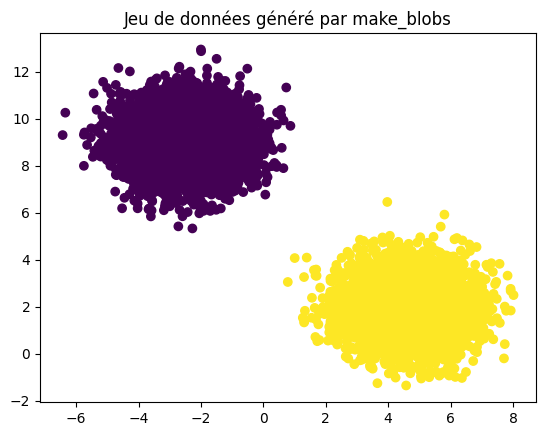

In [ ]:
plt.scatter(x[:, 0], x[:, 1], c=y, cmap='viridis')
plt.title("Jeu de données généré par make_blobs")
plt.show()

#Augmnter data et divise entre train et test (Prepare data)

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
x_train = np.array(x_train)
x_test = np.array(x_test)
y_train = np.array(y_train)
y_test = np.array(y_test)

In [ ]:
vertor_one = np.ones(x_train.shape[0],int)
vertor_one_test = np.ones(x_test.shape[0],int)
vertor_one = vertor_one.reshape(x_train.shape[0],1)
vertor_one_test = vertor_one_test.reshape(x_test.shape[0],1)

In [ ]:
y_train = np.reshape(y_train, (y_train.shape[0],1))
y_test = np.reshape(y_test,(y_test.shape[0],1))

In [ ]:
x_train = np.concatenate((x_train,vertor_one),axis=1)
x_test = np.concatenate((x_test,vertor_one_test),axis=1)

print(x_train.shape)

(8000, 3)


#Algo Precptron

In [ ]:
#def Initialisation

def initialisation(x):
  np.random.seed(6)
  w = np.random.rand(x.shape[1],1)

  return w

In [ ]:
w = initialisation(x_train)
print(w.shape)


(3, 1)


In [ ]:
# def model :
def model (x,w):
  Z = np.dot(x,w)
  A = 1/(1+np.exp(-Z))
  return A

In [ ]:
A = model(x_train,w)
print(A.shape)

(8000, 1)


In [ ]:
def Loss(y, a):
    y = y.flatten()
    a = a.flatten()
    n = y.shape[0]
    epsilon = 1e-10  # لتجنّب log(0)
    L = (-1/n) * np.sum(
        y * np.log(a + epsilon) + (1 - y) * np.log(1 - a + epsilon)
    )
    return L


In [ ]:
L = Loss(y_train,A)


In [ ]:
#Descent de gradient:
def Descent(x,y,a,w,learning_rate):
  n = x.shape[0]
  dw = (1/n)*np.dot(x.T,a-y)
  w = w - learning_rate*dw

  return w

In [ ]:
w = Descent(x_train,y_train,A,w,0.0001)
print(w.shape)


(3, 1)


In [ ]:
#def Precptron:

def Perceptron(X_train,Y_train,X_test,Y_test,learning_rate,epoch):
  w = initialisation(X_train)
  loss = []

  for  i in range(epoch):

    A = model(X_train,w)
    L = Loss(Y_train,A)
    loss.append(L)
    w = Descent(X_train,Y_train,A,w,learning_rate)

  # Evaluer le model
  y_pred = model(X_test,w)
  y_pred = np.where(y_pred>0.6,1,0)
  loss = np.array(loss)
  L = np.mean(loss)
  accuracy = accuracy_score(Y_test,y_pred)
  return L,accuracy


In [ ]:
learning_rate = 0.01
epoch = 390

In [ ]:
loss,acc = Perceptron(x_train,y_train,x_test,y_test,learning_rate,epoch)

In [ ]:

print(f"Loss : {loss:.2f}")
print(f'Accuracy: {acc:.2f}')

Loss : 0.03
Accuracy: 1.00
